<a href="https://colab.research.google.com/github/bellajelly/honors-thesis-2026/blob/main/Depression_CSB_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# The clinical-info metadata file
# One single actigraphy file from a bipolar depression patient

import requests
import zipfile
import pandas as pd
import os

# Define the URL for the file to be downloaded
# This is the direct download link for the OBF-Psychiatric Dataset.zip from Zenodo
url = "https://zenodo.org/records/13754984/files/OBF-Psychiatric%20Dataset.zip?download=1"

# Let's save it to a placeholder filename.
file_name = "OBF-Psychiatric Dataset.zip"

try:
    response = requests.get(url, stream=True)
    response.raise_for_status() # Raise an exception for HTTP errors
    with open(file_name, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print(f"File downloaded successfully to {file_name}")
except requests.exceptions.RequestException as e:
    print(f"Error downloading file: {e}")


File downloaded successfully to OBF-Psychiatric Dataset.zip


In [ ]:
# The zip file name from the previous step
zip_file_name = file_name # 'OBF-Psychiatric Dataset.zip'
extraction_path = './extracted_data'

# Create directory for extraction if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

try:
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall(extraction_path)
    print(f"'{zip_file_name}' extracted to '{extraction_path}' successfully.")
except FileNotFoundError:
    print(f"Error: The file '{zip_file_name}' was not found.")
except zipfile.BadZipFile:
    print(f"Error: '{zip_file_name}' is not a valid zip file.")
except Exception as e:
    print(f"An unexpected error occurred during extraction: {e}")

# List files in the extracted directory
print(f"\nFiles in '{extraction_path}':")
if os.path.exists(extraction_path):
    for root, dirs, files in os.walk(extraction_path):
        for name in files:
            print(os.path.join(root, name))
        for name in dirs:
            print(os.path.join(root, name) + '/')
else:
    print("Extraction path does not exist.")

'OBF-Psychiatric Dataset.zip' extracted to './extracted_data' successfully.

Files in './extracted_data':
./extracted_data/OBF-Psychiatric Dataset/
./extracted_data/OBF-Psychiatric Dataset/README.txt
./extracted_data/OBF-Psychiatric Dataset/schizophrenia-info.csv
./extracted_data/OBF-Psychiatric Dataset/features.csv
./extracted_data/OBF-Psychiatric Dataset/depression-info.csv
./extracted_data/OBF-Psychiatric Dataset/adhd-info.csv
./extracted_data/OBF-Psychiatric Dataset/clinical-info.csv
./extracted_data/OBF-Psychiatric Dataset/control-info.csv
./extracted_data/OBF-Psychiatric Dataset/control/
./extracted_data/OBF-Psychiatric Dataset/adhd/
./extracted_data/OBF-Psychiatric Dataset/schizophrenia/
./extracted_data/OBF-Psychiatric Dataset/clinical/
./extracted_data/OBF-Psychiatric Dataset/depression/
./extracted_data/OBF-Psychiatric Dataset/control/control_16.csv
./extracted_data/OBF-Psychiatric Dataset/control/control_32.csv
./extracted_data/OBF-Psychiatric Dataset/control/control_26.csv


In [ ]:
extraction_path = './extracted_data/OBF-Psychiatric Dataset'
file_name = 'depression-info.csv'
file_path = os.path.join(extraction_path, file_name)

try:
    df_depression_info = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_name}' into a pandas DataFrame.")
    print("First 5 rows of the DataFrame:")
    print(df_depression_info.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded 'depression-info.csv' into a pandas DataFrame.
First 5 rows of the DataFrame:
         number  days  gender    age  afftype  melanch  inpatient  marriage  \
0  depression_1    11       2  35-39        2      2.0          2         1   
1  depression_2    18       2  40-44        1      2.0          2         2   
2  depression_3    13       1  45-49        2      2.0          2         2   
3  depression_4    13       2  25-29        2      2.0          2         1   
4  depression_5    13       2  50-54        2      2.0          2         2   

   work  madrs1  madrs2  acc_time  migraine  
0     2      19      19  12:00:00         1  
1     2      24      11  15:00:00         1  
2     2      24      25  15:00:00         1  
3     1      20      16  11:59:00         1  
4     2      26      26  10:30:00         0  


In [ ]:
extraction_path = './extracted_data/OBF-Psychiatric Dataset/depression'
file_name = 'depression_18.csv'
file_path = os.path.join(extraction_path, file_name)

try:
    df_depression_info2 = pd.read_csv(file_path)
    print(f"Successfully loaded '{file_name}' into a pandas DataFrame.")
    print("All rows of the DataFrame:")
    # Printing the entire DataFrame directly
    print(df_depression_info2)
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded 'depression_18.csv' into a pandas DataFrame.
All rows of the DataFrame:
                 timestamp        date  activity
0      2005-11-08 12:30:00  2005-11-08         0
1      2005-11-08 12:31:00  2005-11-08         0
2      2005-11-08 12:32:00  2005-11-08         0
3      2005-11-08 12:33:00  2005-11-08         0
4      2005-11-08 12:34:00  2005-11-08         0
...                    ...         ...       ...
21342  2005-11-23 08:12:00  2005-11-23         0
21343  2005-11-23 08:13:00  2005-11-23         0
21344  2005-11-23 08:14:00  2005-11-23         2
21345  2005-11-23 08:15:00  2005-11-23         0
21346  2005-11-23 08:16:00  2005-11-23       326

[21347 rows x 3 columns]


In [ ]:
def get_madrs_category(score):
    # return a category label based on score
    if score < 9:
        return "depressive symptoms absent"
    elif score < 18:
        return "Mild depression"
    elif score < 35:
        return "Moderate depression"
    else:
        return "Severe depression"

def is_transitioning(madrs1, madrs2):
    # get category for each
    # compare them
    # return True if different, False if same
    madrs1_category = get_madrs_category(madrs1)
    madrs2_category = get_madrs_category(madrs2)
    if madrs1_category != madrs2_category:
        return True
    else:
        return False


In [ ]:
# apply is_transitioning to each row of your metadata dataframe
# and store the result in a new column called 'transitioning'

# Now apply the function, assuming df_depression_info has been correctly loaded
df_depression_info['transitioning'] = df_depression_info.apply(lambda row: is_transitioning(madrs1=row['madrs1'], madrs2=row['madrs2']), axis=1)
print(df_depression_info['transitioning'].value_counts())
print(f"Total patients: {len(df_depression_info)}")

transitioning
False    16
True      7
Name: count, dtype: int64
Total patients: 23


In [ ]:
def compute_daily_summary(df_actigraphy):
    # df_actigraphy has columns: timestamp, date, activity

    # step 1: make sure timestamp is datetime format
    df_actigraphy['timestamp'] = pd.to_datetime(df_actigraphy['timestamp'])

    # step 2: extract hour from timestamp
    df_actigraphy['hour'] = df_actigraphy['timestamp'].dt.hour

    # step 3: group by date and hour, compute mean activity per hour
    hourly = df_actigraphy.groupby(['date', 'hour'])['activity'].mean()

    # step 4: group by date, compute mean and std of those hourly means
    daily = hourly.groupby(level='date').agg(['mean', 'std'])

    # return a dataframe with columns: date, mean_hourly_activity, std_hourly_activity
    # filter to complete days only
    hours_per_day = hourly.groupby(level='date').count()
    daily = daily[daily.index.isin(hours_per_day[hours_per_day >= 20].index)]

    # rename columns clearly
    daily.columns = ['mean_hourly_activity', 'std_hourly_activity']

    return daily.reset_index()


In [ ]:
daily_summary = compute_daily_summary(df_depression_info2)
print(daily_summary)
print(daily_summary.shape)

          date  mean_hourly_activity  std_hourly_activity
0   2005-11-09             58.068056            37.524599
1   2005-11-10             67.372222            52.942633
2   2005-11-11             72.817361            47.086134
3   2005-11-12             77.766667            48.923059
4   2005-11-13             86.177083            65.239282
5   2005-11-14             65.537500            40.483277
6   2005-11-15             67.665972            56.530699
7   2005-11-16             67.579861            40.920418
8   2005-11-17             72.039583            59.747052
9   2005-11-18             81.670139            71.691084
10  2005-11-19             74.499306            56.810763
11  2005-11-20             65.329167            61.705234
12  2005-11-21             86.878472            93.737628
13  2005-11-22             56.736111            78.587453
(14, 3)


In [ ]:
def compute_csd_features(daily_summary, window_size):
    # daily_summary has columns: date, mean_hourly_activity, std_hourly_activity
    mean_activity = daily_summary['mean_hourly_activity']
    std_activity = daily_summary['std_hourly_activity']

    # step 1: compute rolling variance of mean_hourly_activity
    rolling_variance_mean = mean_activity.rolling(window_size).var()

    # step 2: compute rolling lag-1 autocorrelation of mean_hourly_activity
    rolling_autocorr_mean = mean_activity.rolling(window_size).apply(lambda x: x.autocorr())

    # step 3: compute rolling variance of std_hourly_activity
    rolling_variance_std = std_activity.rolling(window_size).var()

    # step 4: compute rolling lag-1 autocorrelation of std_hourly_activity
    rolling_autocorr_std = std_activity.rolling(window_size).apply(lambda x: x.autocorr())

    # step 5: take average of last 3 values of each
    feat_var_mean = rolling_variance_mean.dropna().tail(3).mean()
    feat_autocorr_mean = rolling_autocorr_mean.dropna().tail(3).mean()
    feat_var_std = rolling_variance_std.dropna().tail(3).mean()
    feat_autocorr_std = rolling_autocorr_std.dropna().tail(3).mean()

    # return a dictionary with 4 CSD feature values
    return {
    'var_mean_activity': feat_var_mean,
    'autocorr_mean_activity': feat_autocorr_mean,
    'var_std_activity': feat_var_std,
    'autocorr_std_activity': feat_autocorr_std
    }


In [ ]:
# test with both window sizes
features_3 = compute_csd_features(daily_summary, window_size=3)
features_5 = compute_csd_features(daily_summary, window_size=5)

print("Window size 3:", features_3)
print("Window size 5:", features_5)

Window size 3: {'var_mean_activity': np.float64(141.72347570516112), 'autocorr_mean_activity': np.float64(-0.3333333333333333), 'var_std_activity': np.float64(238.85176763138443), 'autocorr_std_activity': np.float64(-0.33333333333333326)}
Window size 5: {'var_mean_activity': np.float64(86.59935961612666), 'autocorr_mean_activity': np.float64(-0.49179212700573643), 'var_std_activity': np.float64(187.90711532788256), 'autocorr_std_activity': np.float64(-0.08773872098744136)}


In [ ]:
results_depression = []

# loop through depression patients
for idx, row in df_depression_info.iterrows():
    patient_id = row['number']
    extraction_path = './extracted_data/OBF-Psychiatric Dataset/depression'

    # step 1: load the patient's actigraphy file
    file_path = os.path.join(extraction_path, f"{patient_id}.csv")
    try:
        df_patient = pd.read_csv(file_path)
        # The problematic print statement and control-related lines have been removed from here.

        # step 2: compute daily summary
        daily_summary = compute_daily_summary(df_patient)
        # step 3: compute CSD features for both window sizes
        features_3 = compute_csd_features(daily_summary, window_size=3)
        features_5 = compute_csd_features(daily_summary, window_size=5)
        # step 4: determine group label (transitioning or stable)
        group = 'transitioning' if row['transitioning'] else 'stable'
        # step 5: store everything in a dictionary and append to results
        results_depression.append({
                'patient_id': patient_id,
                'group': group,
                'madrs1': row['madrs1'],
                'madrs2': row['madrs2'],
                'afftype': row['afftype'],
                **{f'w3_{k}': v for k, v in features_3.items()},
                **{f'w5_{k}': v for k, v in features_5.items()}
            })
    except FileNotFoundError:
        print(f"Error: Actigraphy file not found for depression patient {patient_id} at {file_path}")
    except Exception as e:
        print(f"An unexpected error occurred for depression patient {patient_id}: {e}")

df_results_depression = pd.DataFrame(results_depression)
print(df_results_depression.shape)
print(df_results_depression['group'].value_counts())
print(df_results_depression.head())

# Load df_control_info before looping through control patients
control_info_path = os.path.join('./extracted_data/OBF-Psychiatric Dataset', 'control-info.csv')
try:
    df_control_info = pd.read_csv(control_info_path)
    print("Successfully loaded 'control-info.csv' into a pandas DataFrame.")
except FileNotFoundError:
    print(f"Error: The file '{control_info_path}' for control patients was not found.")
    df_control_info = pd.DataFrame() # Create an empty DataFrame to prevent further errors if not found
except Exception as e:
    print(f"An error occurred while reading the control CSV file: {e}")

# loop through control patients

results_control = []

for idx, row in df_control_info.iterrows():
    control_id = row['number']
    extraction_path = './extracted_data/OBF-Psychiatric Dataset/control'

    # step 1: load the patient's actigraphy file
    file_path = os.path.join(extraction_path, f"{control_id}.csv")

    try:
        df_control = pd.read_csv(file_path)
    # step 2: compute daily summary
        daily_summary_control = compute_daily_summary(df_control)
    # step 3: compute CSD features for both window sizes
        features_3 = compute_csd_features(daily_summary_control, window_size=3)
        features_5 = compute_csd_features(daily_summary_control, window_size=5)

    # step 4: store everything in a dictionary and append to results
        results_control.append({
            'patient_id': control_id,
            'group': 'control',
            **{f'w3_{k}': v for k, v in features_3.items()},
            **{f'w5_{k}': v for k, v in features_5.items()}
        })
    except FileNotFoundError:
        print(f"Error: Actigraphy file not found for control patient {control_id} at {file_path}")
    except Exception as e:
        print(f"An unexpected error occurred for control patient {control_id}: {e}")

# convert results to dataframe
df_results_control = pd.DataFrame(results_control)
print(df_results_control.shape)
print(df_results_control['group'].value_counts())
print(df_results_control.head())

(23, 13)
group
stable           16
transitioning     7
Name: count, dtype: int64
     patient_id          group  madrs1  madrs2  afftype  w3_var_mean_activity  \
0  depression_1         stable      19      19        2           2567.166678   
1  depression_2  transitioning      24      11        1              0.128260   
2  depression_3         stable      24      25        2           2697.281384   
3  depression_4  transitioning      20      16        2          40702.024476   
4  depression_5         stable      26      26        2           2337.441435   

   w3_autocorr_mean_activity  w3_var_std_activity  w3_autocorr_std_activity  \
0                  -1.000000         18573.765929                 -1.000000   
1                   0.333333             0.200183                  0.333333   
2                   0.333333          3732.237245                 -1.000000   
3                  -0.333333         25318.901588                 -0.333333   
4                  -1.000000         

In [ ]:
# step 1: combine depression and control results
df_all = pd.concat([df_results_depression, df_results_control], ignore_index=True)

# step 2: identify your feature columns
feature_cols = [col for col in df_all.columns if col.startswith('w3_') or col.startswith('w5_')]

# step 3: z-score each feature column across all patients
from scipy import stats
df_all[feature_cols] = df_all[feature_cols].apply(stats.zscore)

print(df_all.groupby('group')[feature_cols].mean())

               w3_var_mean_activity  w3_autocorr_mean_activity  \
group                                                            
control                    0.023519                   0.049923   
stable                    -0.271643                  -0.185427   
transitioning              0.513380                   0.195615   

               w3_var_std_activity  w3_autocorr_std_activity  \
group                                                          
control                  -0.105334                 -0.022655   
stable                    0.021837                  0.046568   
transitioning             0.431612                 -0.002877   

               w5_var_mean_activity  w5_autocorr_mean_activity  \
group                                                            
control                   -0.012203                   0.006187   
stable                    -0.117301                   0.138155   
transitioning              0.323901                  -0.344068   

               w5

In [ ]:
import scipy.stats as stats

variance_features = [
    'w3_var_mean_activity',
    'w3_var_std_activity',
    'w5_var_mean_activity',
    'w5_var_std_activity'
]

for feature in variance_features:
    transitioning = df_all[df_all['group'] == 'transitioning'][feature]
    stable = df_all[df_all['group'] == 'stable'][feature]
    control = df_all[df_all['group'] == 'control'][feature]

    stat, p_value = stats.kruskal(transitioning, stable, control)
    print(f"{feature}: H={stat:.3f}, p={p_value:.3f}")

w3_var_mean_activity: H=1.246, p=0.536
w3_var_std_activity: H=3.414, p=0.181
w5_var_mean_activity: H=0.400, p=0.819
w5_var_std_activity: H=1.606, p=0.448


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ============================================
# PART 1: PERMUTATION TESTS (Monte Carlo)
# ============================================

def permutation_test_two_sided(group_a, group_b, n_permutations=10000, random_seed=42):
    """
    Monte Carlo permutation test for difference in means.

    Returns:
        p_value: proportion of permutations with difference >= observed
        observed_diff: actual mean difference
        effect_size: Cohen's d (pooled standard deviation)
    """
    np.random.seed(random_seed)

    observed_diff = np.mean(group_a) - np.mean(group_b)
    pooled = np.concatenate([group_a, group_b])
    n_a = len(group_a)
    n_b = len(group_b)

    # Monte Carlo sampling
    perm_diffs = []
    for _ in range(n_permutations):
        permuted = np.random.permutation(pooled)
        perm_diff = np.mean(permuted[:n_a]) - np.mean(permuted[n_a:])
        perm_diffs.append(perm_diff)

    # Two-sided p-value: proportion of permutations with |diff| >= |observed_diff|
    perm_diffs = np.array(perm_diffs)
    p_value = np.mean(np.abs(perm_diffs) >= np.abs(observed_diff))

    # Cohen's d (using pooled standard deviation)
    var_a = np.var(group_a, ddof=1)
    var_b = np.var(group_b, ddof=1)
    pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    cohens_d = observed_diff / pooled_std if pooled_std > 0 else 0

    return {
        'p_value': p_value,
        'observed_diff': observed_diff,
        'cohens_d': cohens_d,
        'permutation_distribution': perm_diffs
    }

# Run tests for variance features
features = ['w3_var_mean_activity', 'w3_var_std_activity',
            'w5_var_mean_activity', 'w5_var_std_activity']

results_summary = []

for feature in features:
    # Extract data
    transitioning = df_all[df_all['group'] == 'transitioning'][feature].dropna().values
    stable = df_all[df_all['group'] == 'stable'][feature].dropna().values
    control = df_all[df_all['group'] == 'control'][feature].dropna().values

    # Transitioning vs Stable
    ts = permutation_test_two_sided(transitioning, stable)
    # Transitioning vs Control
    tc = permutation_test_two_sided(transitioning, control)

    results_summary.append({
        'feature': feature,
        'trans_vs_stable_p': ts['p_value'],
        'trans_vs_stable_d': ts['cohens_d'],
        'trans_vs_control_p': tc['p_value'],
        'trans_vs_control_d': tc['cohens_d'],
        'mean_trans': np.mean(transitioning),
        'mean_stable': np.mean(stable),
        'mean_control': np.mean(control)
    })

# Display results
results_df = pd.DataFrame(results_summary)
print("\n" + "="*60)
print("PERMUTATION TEST RESULTS (10,000 iterations)")
print("="*60)
print(results_df.round(4).to_string())
print("\nNote: p-values < 0.10 suggest promising effects for pilot study")

# ============================================
# PART 2: INDIVIDUAL TRAJECTORY PLOTS
# ============================================

# First, you need to get the daily variance time series for each patient
# Assuming you have the raw daily_summary data before aggregation

def plot_individual_trajectories(patients_daily_data, transitioning_patient_ids, save_path=None):
    """
    patients_daily_data: dict with patient_id -> DataFrame with 'day' and 'daily_variance'
    transitioning_patient_ids: list of IDs to plot
    """
    n_patients = len(transitioning_patient_ids)
    fig, axes = plt.subplots(n_patients, 1, figsize=(12, 4*n_patients))

    if n_patients == 1:
        axes = [axes]

    for idx, patient_id in enumerate(transitioning_patient_ids):
        df_patient = patients_daily_data[patient_id]

        # Calculate rolling variance (window=3)
        df_patient['rolling_var'] = df_patient['daily_variance'].rolling(window=3, min_periods=2).mean()

        ax = axes[idx]
        ax.plot(df_patient['day'], df_patient['daily_variance'], 'o-', alpha=0.5,
                label='Daily variance', markersize=4)
        ax.plot(df_patient['day'], df_patient['rolling_var'], 's-', color='red',
                label='3-day rolling variance', linewidth=2)

        # Mark the transition point (when second MADRS occurred)
        if 'transition_day' in df_patient.columns:
            ax.axvline(x=df_patient['transition_day'].iloc[0], color='black',
                      linestyle='--', label='MADRS assessment 2')

        ax.set_title(f'Patient {patient_id} (Transitioning)', fontweight='bold')
        ax.set_xlabel('Day of recording')
        ax.set_ylabel('Variance of hourly activity')
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

# Example of how to prepare the data (you'll need to adapt this to your structure)
# patients_daily_data = {}
# for patient_id in transitioning_patient_ids:
#     # Load daily_summary from your earlier computation
#     daily_var = ... # Series of daily variance values
#     patients_daily_data[patient_id] = pd.DataFrame({
#         'day': range(1, len(daily_var)+1),
#         'daily_variance': daily_var,
#         'transition_day': day_of_second_madrs  # if known
#     })

# Call the function:
# plot_individual_trajectories(patients_daily_data, transitioning_patient_ids,
#                              save_path='transitioning_trajectories.png')


PERMUTATION TEST RESULTS (10,000 iterations)
                feature  trans_vs_stable_p  trans_vs_stable_d  trans_vs_control_p  trans_vs_control_d  mean_trans  mean_stable  mean_control
0  w3_var_mean_activity             0.0686             0.8033              0.3361              0.4208      0.5134      -0.2716        0.0235
1   w3_var_std_activity             0.4298             0.3811              0.2305              0.5007      0.4316       0.0218       -0.1053
2  w5_var_mean_activity             0.4330             0.3908              0.4454              0.3292      0.3239      -0.1173       -0.0122
3   w5_var_std_activity             0.9235             0.0451              0.2871              0.4513      0.2372       0.1781       -0.1410

Note: p-values < 0.10 suggest promising effects for pilot study


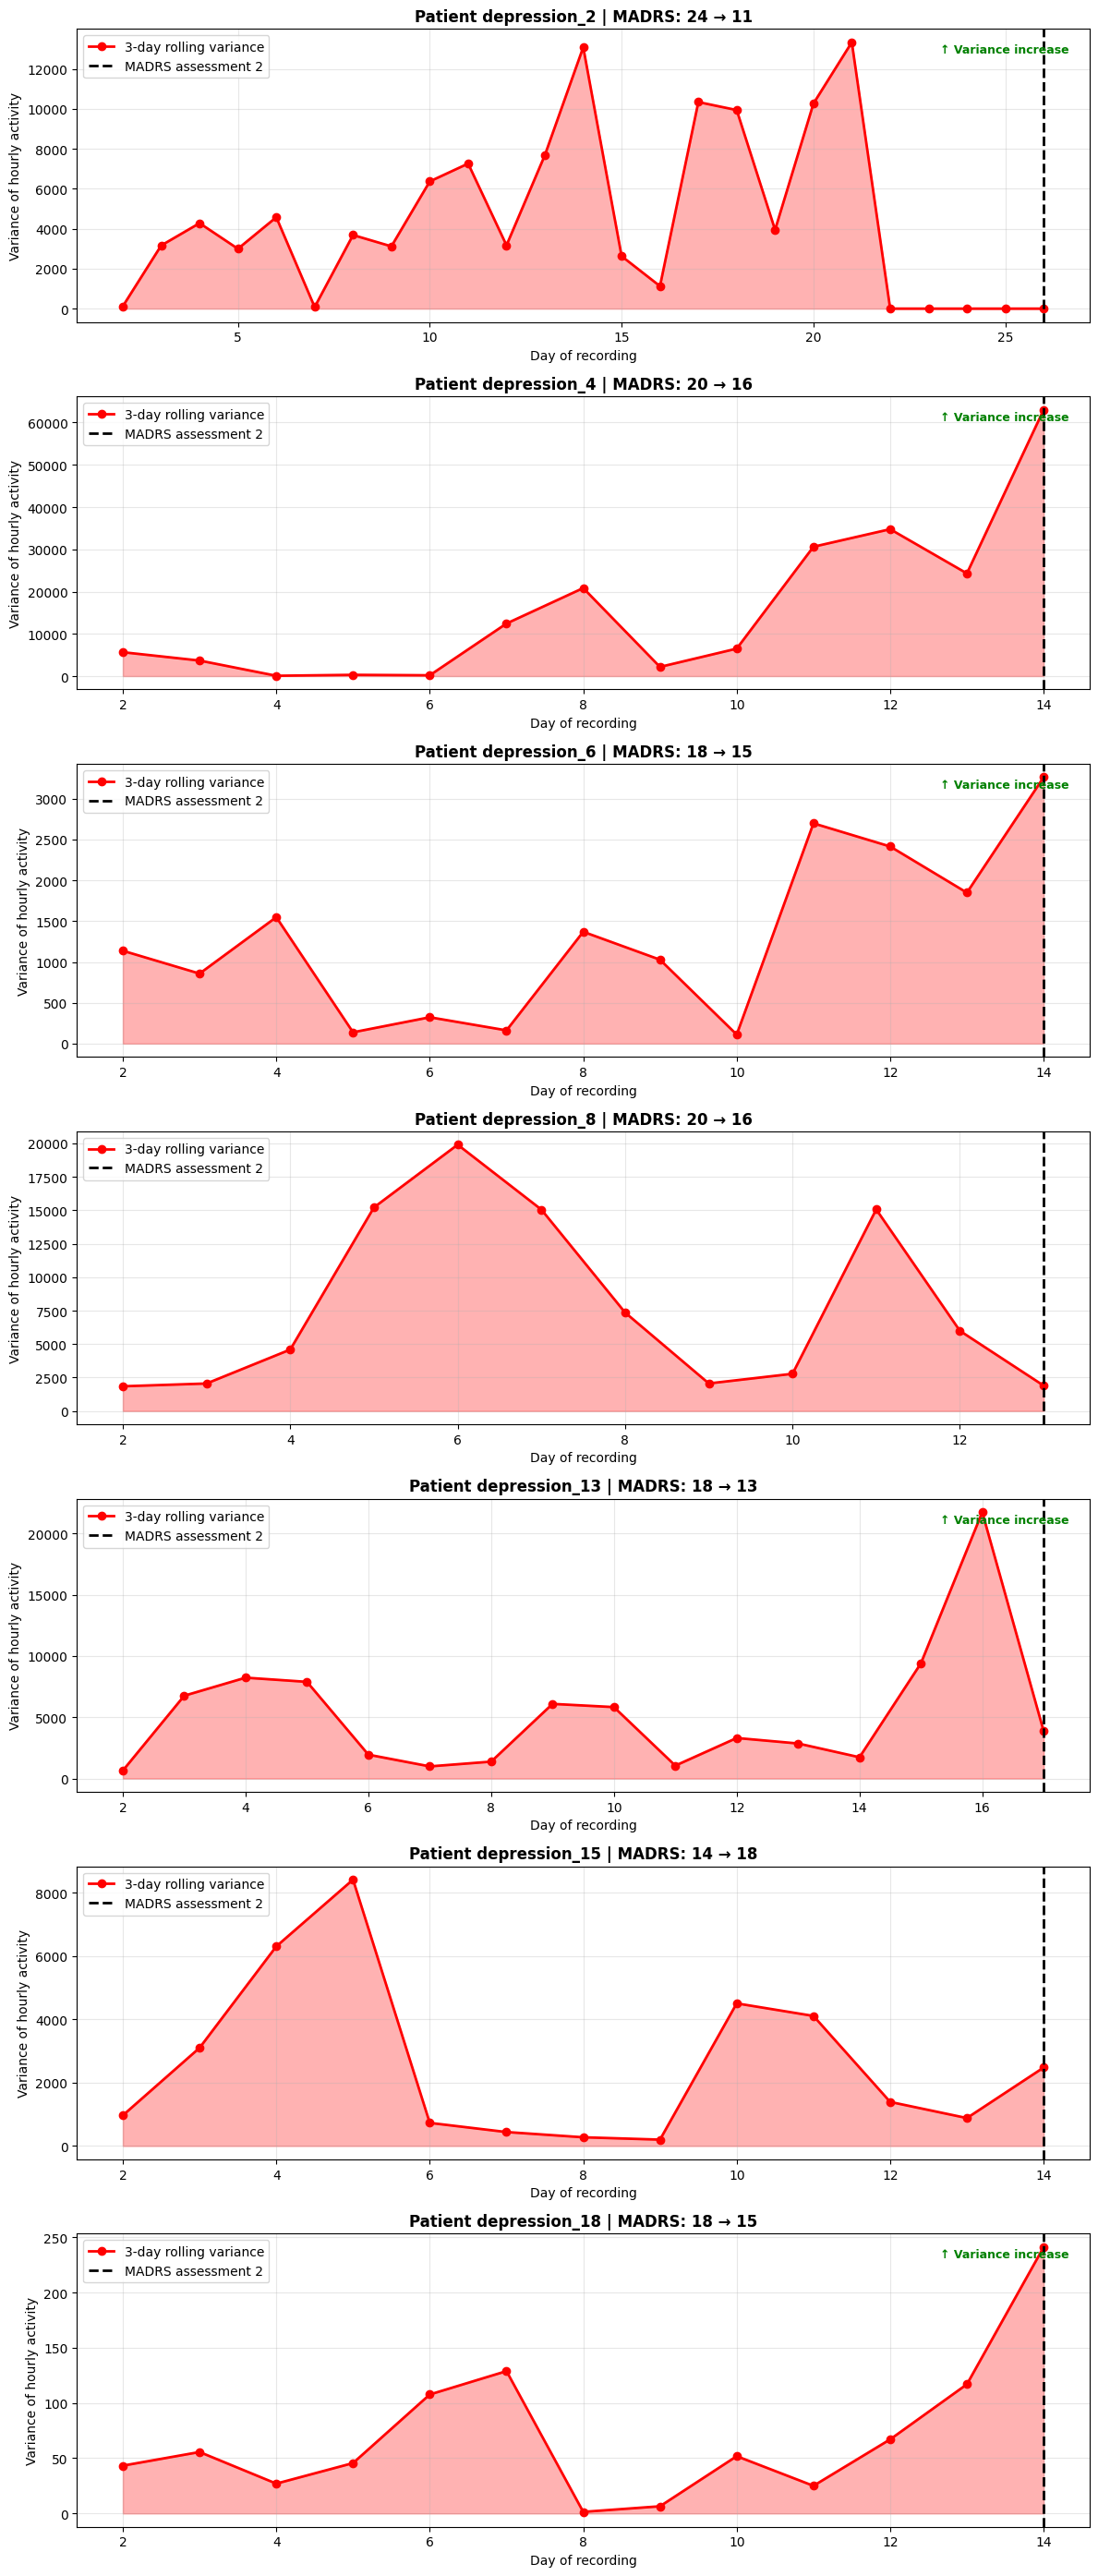


Variance increase observed in 5 out of 7 transitioning patients


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Create a dictionary to store daily trajectories for transitioning patients
transitioning_patients = df_all[df_all['group'] == 'transitioning']['patient_id'].tolist()
daily_trajectories = {}

for patient_id in transitioning_patients:
    # Reload the patient's actigraphy file (or retrieve from cached data)
    file_path = f"./extracted_data/OBF-Psychiatric Dataset/depression/{patient_id}.csv"

    try:
        df_patient = pd.read_csv(file_path)

        # Compute daily summary (reuse your compute_daily_summary function)
        daily_summary = compute_daily_summary(df_patient)

        # Compute 3-day rolling variance of mean hourly activity
        daily_summary['rolling_var_3day'] = daily_summary['mean_hourly_activity'].rolling(
            window=3, min_periods=2
        ).var()

        # Store in dictionary
        daily_trajectories[patient_id] = daily_summary[['mean_hourly_activity', 'rolling_var_3day']].copy()
        daily_trajectories[patient_id]['day'] = range(1, len(daily_summary) + 1)
        daily_trajectories[patient_id]['transition_day'] = len(daily_summary)

    except Exception as e:
        print(f"Error processing patient {patient_id}: {e}")

# Plot individual trajectories
fig, axes = plt.subplots(len(transitioning_patients), 1, figsize=(12, 4*len(transitioning_patients)))
if len(transitioning_patients) == 1:
    axes = [axes]

for idx, patient_id in enumerate(transitioning_patients):
    df_traj = daily_trajectories[patient_id]

    ax = axes[idx]

    # Plot rolling variance
    ax.plot(df_traj['day'], df_traj['rolling_var_3day'], 'o-', color='red',
            linewidth=2, markersize=6, label='3-day rolling variance')

    # Add shaded area for variance increase
    ax.fill_between(df_traj['day'], 0, df_traj['rolling_var_3day'],
                    alpha=0.3, color='red')

    # Mark transition point
    ax.axvline(x=df_traj['transition_day'].iloc[0], color='black',
              linestyle='--', linewidth=2, label='MADRS assessment 2')

    # Add patient info
    madrs1 = df_all[df_all['patient_id'] == patient_id]['madrs1'].values[0]
    madrs2 = df_all[df_all['patient_id'] == patient_id]['madrs2'].values[0]
    ax.set_title(f'Patient {patient_id} | MADRS: {madrs1:.0f} → {madrs2:.0f}',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Day of recording', fontsize=10)
    ax.set_ylabel('Variance of hourly activity', fontsize=10)
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

    # Add annotation if variance increases
    first_half_var = df_traj['rolling_var_3day'].iloc[:len(df_traj)//2].mean()
    second_half_var = df_traj['rolling_var_3day'].iloc[len(df_traj)//2:].mean()
    if second_half_var > first_half_var:
        ax.text(0.98, 0.95, '↑ Variance increase', transform=ax.transAxes,
               ha='right', va='top', fontsize=9, color='green', fontweight='bold')

plt.tight_layout()
plt.savefig('transitioning_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

# Count how many show variance increase
increase_count = 0
for patient_id in transitioning_patients:
    df_traj = daily_trajectories[patient_id]
    first_half = df_traj['rolling_var_3day'].iloc[:len(df_traj)//2].mean()
    second_half = df_traj['rolling_var_3day'].iloc[len(df_traj)//2:].mean()
    if second_half > first_half:
        increase_count += 1

print(f"\nVariance increase observed in {increase_count} out of {len(transitioning_patients)} transitioning patients")

/tmp/ipykernel_51566/3024300837.py:151: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(boxplot_data, labels=['Control\n(n=32)', 'Stable Depressed\n(n=16)', 'Transitioning\n(n=7)'],


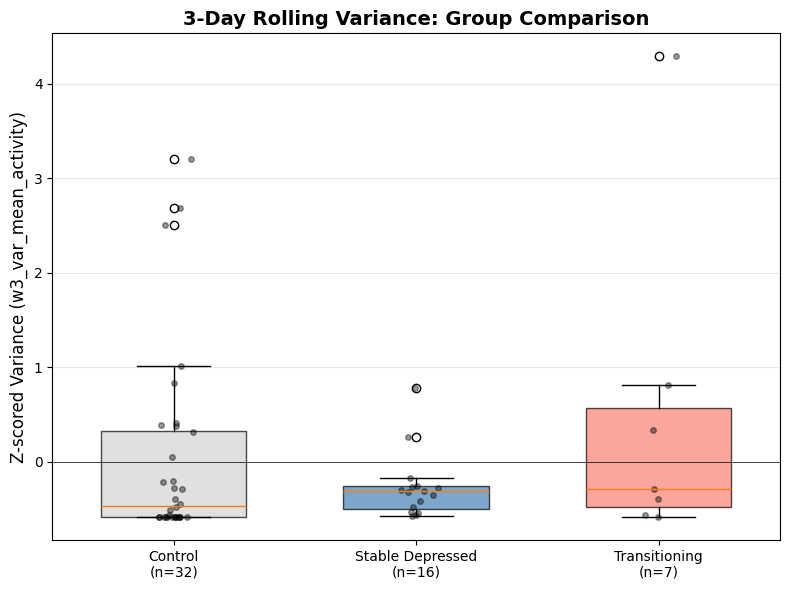


SUMMARY STATISTICS FOR PRESENTATION

Transitioning Patients (n=7):
  Mean w3_var = 0.513
  SD = 1.744

Stable Depressed Patients (n=16):
  Mean w3_var = -0.272
  SD = 0.348

Healthy Controls (n=32):
  Mean w3_var = 0.024
  SD = 1.014

Stable patients with below-average variance (<0): 14/16 (88%)


In [ ]:

# ============================================
# PLOT STABLE DEPRESSED PATIENTS
# ============================================

# Get lists of patient IDs for both groups
transitioning_patients = df_all[df_all['group'] == 'transitioning']['patient_id'].tolist()
stable_patients = df_all[df_all['group'] == 'stable']['patient_id'].tolist()
control_patients = df_all[df_all['group'] == 'control']['patient_id'].tolist()

# Dictionary to store daily trajectories for BOTH groups
daily_trajectories = {}

# Process transitioning patients
for patient_id in transitioning_patients:
    file_path = f"./extracted_data/OBF-Psychiatric Dataset/depression/{patient_id}.csv"

    try:
        df_patient = pd.read_csv(file_path)
        daily_summary = compute_daily_summary(df_patient)
        daily_summary['rolling_var_3day'] = daily_summary['mean_hourly_activity'].rolling(
            window=3, min_periods=2
        ).var()
        daily_summary['patient_id'] = patient_id
        daily_summary['group'] = 'transitioning'
        daily_summary['day'] = range(1, len(daily_summary) + 1)
        daily_trajectories[patient_id] = daily_summary

        # Get MADRS scores
        madrs1 = df_all[df_all['patient_id'] == patient_id]['madrs1'].values[0]
        madrs2 = df_all[df_all['patient_id'] == patient_id]['madrs2'].values[0]
        daily_summary['madrs_info'] = f"{madrs1:.0f}→{madrs2:.0f}"

    except Exception as e:
        print(f"Error processing transitioning patient {patient_id}: {e}")

# Process stable patients
for patient_id in stable_patients:
    file_path = f"./extracted_data/OBF-Psychiatric Dataset/depression/{patient_id}.csv"

    try:
        df_patient = pd.read_csv(file_path)
        daily_summary = compute_daily_summary(df_patient)
        daily_summary['rolling_var_3day'] = daily_summary['mean_hourly_activity'].rolling(
            window=3, min_periods=2
        ).var()
        daily_summary['patient_id'] = patient_id
        daily_summary['group'] = 'stable'
        daily_summary['day'] = range(1, len(daily_summary) + 1)
        daily_trajectories[patient_id] = daily_summary

        # Get MADRS scores
        madrs1 = df_all[df_all['patient_id'] == patient_id]['madrs1'].values[0]
        madrs2 = df_all[df_all['patient_id'] == patient_id]['madrs2'].values[0]
        daily_summary['madrs_info'] = f"{madrs1:.0f}→{madrs2:.0f}"

    except Exception as e:
        print(f"Error processing stable patient {patient_id}: {e}")
"""
# ============================================
# OPTION 1: Individual plots for stable patients only
# ============================================

n_stable = len(stable_patients)
fig, axes = plt.subplots(n_stable, 1, figsize=(12, 4*n_stable))
if n_stable == 1:
    axes = [axes]

for idx, patient_id in enumerate(stable_patients):
    df_traj = daily_trajectories[patient_id]
    madrs_info = df_traj['madrs_info'].iloc[0]

    ax = axes[idx]

    # Plot rolling variance
    ax.plot(df_traj['day'], df_traj['rolling_var_3day'], 'o-', color='steelblue',
            linewidth=1.5, markersize=4, label='3-day rolling variance')

    # Add horizontal line for mean variance
    mean_var = df_traj['rolling_var_3day'].mean()
    ax.axhline(y=mean_var, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Mean = {mean_var:.3f}')

    ax.set_title(f'Stable Patient {patient_id} (MADRS: {madrs_info})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Day of recording')
    ax.set_ylabel('Variance of hourly activity')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

    # Set y-axis limits to be consistent across patients
    ax.set_ylim(bottom=0)

plt.suptitle('Stable Depressed Patients: 3-Day Rolling Variance Trajectories', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('stable_patients_individual.png', dpi=150, bbox_inches='tight')
plt.show()
"""
"""
# ============================================
# OPTION 2: Side-by-side comparison (Transitioning vs Stable)
# ============================================

# Pick a subset for clarity (e.g., first 3 transitioning, first 3 stable)
n_compare = min(3, len(transitioning_patients), len(stable_patients))
fig, axes = plt.subplots(2, n_compare, figsize=(4*n_compare, 8))

for i in range(n_compare):
    # Transitioning patient
    trans_id = transitioning_patients[i]
    trans_df = daily_trajectories[trans_id]
    madrs_trans = trans_df['madrs_info'].iloc[0]

    ax = axes[0, i]
    ax.plot(trans_df['day'], trans_df['rolling_var_3day'], 'o-', color='red', linewidth=2, markersize=5)
    ax.set_title(f'Transitioning {trans_id}\n(MADRS: {madrs_trans})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Day')
    ax.set_ylabel('Variance')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

    # Stable patient
    stable_id = stable_patients[i]
    stable_df = daily_trajectories[stable_id]
    madrs_stable = stable_df['madrs_info'].iloc[0]

    ax = axes[1, i]
    ax.plot(stable_df['day'], stable_df['rolling_var_3day'], 'o-', color='steelblue', linewidth=2, markersize=5)
    ax.set_title(f'Stable {stable_id}\n(MADRS: {madrs_stable})', fontsize=10, fontweight='bold')
    ax.set_xlabel('Day')
    ax.set_ylabel('Variance')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)

plt.suptitle('Comparing 3-Day Rolling Variance: Transitioning (red) vs Stable (blue)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('transitioning_vs_stable_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

"""
# ============================================
# OPTION 3: Boxplot comparing all three groups (using the aggregated feature)
# ============================================

fig, ax = plt.subplots(figsize=(8, 6))

# Prepare data for boxplot
boxplot_data = [
    df_all[df_all['group'] == 'control']['w3_var_mean_activity'].dropna(),
    df_all[df_all['group'] == 'stable']['w3_var_mean_activity'].dropna(),
    df_all[df_all['group'] == 'transitioning']['w3_var_mean_activity'].dropna()
]

bp = ax.boxplot(boxplot_data, labels=['Control\n(n=32)', 'Stable Depressed\n(n=16)', 'Transitioning\n(n=7)'],
                patch_artist=True, widths=0.6)

# Customize colors
colors = ['lightgray', 'steelblue', 'salmon']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Add individual points
for i, data in enumerate(boxplot_data):
    x = np.random.normal(i+1, 0.04, size=len(data))
    ax.plot(x, data, 'o', color='black', alpha=0.4, markersize=4)

ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax.set_ylabel('Z-scored Variance (w3_var_mean_activity)', fontsize=12)
ax.set_title('3-Day Rolling Variance: Group Comparison', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('group_comparison_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================
# OPTION 4: Summary statistics for your presentation
# ============================================

print("\n" + "="*60)
print("SUMMARY STATISTICS FOR PRESENTATION")
print("="*60)

print(f"\nTransitioning Patients (n={len(transitioning_patients)}):")
print(f"  Mean w3_var = {df_all[df_all['group']=='transitioning']['w3_var_mean_activity'].mean():.3f}")
print(f"  SD = {df_all[df_all['group']=='transitioning']['w3_var_mean_activity'].std():.3f}")

print(f"\nStable Depressed Patients (n={len(stable_patients)}):")
print(f"  Mean w3_var = {df_all[df_all['group']=='stable']['w3_var_mean_activity'].mean():.3f}")
print(f"  SD = {df_all[df_all['group']=='stable']['w3_var_mean_activity'].std():.3f}")

print(f"\nHealthy Controls (n={len(control_patients)}):")
print(f"  Mean w3_var = {df_all[df_all['group']=='control']['w3_var_mean_activity'].mean():.3f}")
print(f"  SD = {df_all[df_all['group']=='control']['w3_var_mean_activity'].std():.3f}")

# Count how many stable patients show variance patterns
low_variance_stable = sum(df_all[df_all['group']=='stable']['w3_var_mean_activity'] < 0)
print(f"\nStable patients with below-average variance (<0): {low_variance_stable}/{len(stable_patients)} ({100*low_variance_stable/len(stable_patients):.0f}%)")

BOOTSTRAP CONFIDENCE INTERVALS (95%)

Transitioning vs Stable:
  Cohen's d = 0.803
  95% CI = [-0.674, 1.020]
  Interpretation: Contains zero (not significant at α=0.05)

Transitioning vs Control:
  Cohen's d = 0.421
  95% CI = [-0.646, 0.949]


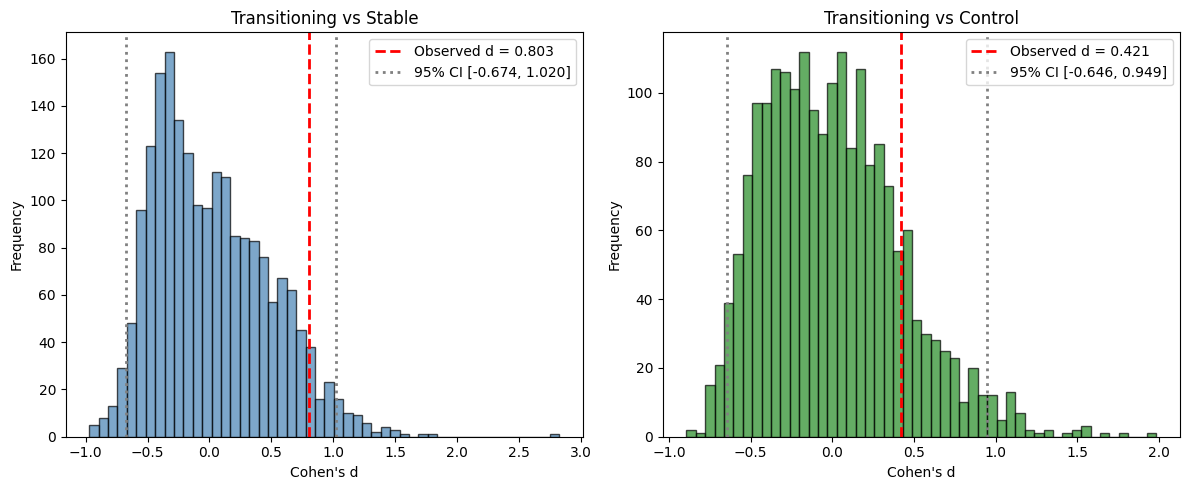


Probability that true effect is at least small (d > 0.2): 0.330
Probability that true effect is at least medium (d > 0.5): 0.171


In [ ]:
def bootstrap_cohens_d_ci(group_a, group_b, n_bootstrap=2000, confidence=0.95):
    """
    Bootstrap confidence interval for Cohen's d

    Parameters:
    - group_a, group_b: arrays of values
    - n_bootstrap: number of bootstrap resamples
    - confidence: confidence level (default 0.95 for 95% CI)

    Returns:
    - cohens_d: observed Cohen's d
    - ci_lower, ci_upper: confidence interval bounds
    - all_d: array of all bootstrap d values
    """
    # Calculate observed Cohen's d
    n_a, n_b = len(group_a), len(group_b)
    mean_a, mean_b = np.mean(group_a), np.mean(group_b)
    var_a, var_b = np.var(group_a, ddof=1), np.var(group_b, ddof=1)
    pooled_std = np.sqrt(((n_a - 1) * var_a + (n_b - 1) * var_b) / (n_a + n_b - 2))
    observed_d = (mean_a - mean_b) / pooled_std

    # Bootstrap resampling
    all_d = []
    combined = np.concatenate([group_a, group_b])
    n_a_orig = n_a

    for _ in range(n_bootstrap):
        # Resample with replacement
        bootstrap_sample = np.random.choice(combined, size=len(combined), replace=True)
        bootstrap_a = bootstrap_sample[:n_a_orig]
        bootstrap_b = bootstrap_sample[n_a_orig:]

        # Calculate d for this bootstrap sample
        m_a, m_b = np.mean(bootstrap_a), np.mean(bootstrap_b)
        v_a, v_b = np.var(bootstrap_a, ddof=1), np.var(bootstrap_b, ddof=1)
        pooled_sd = np.sqrt(((n_a_orig - 1) * v_a + (n_b - 1) * v_b) / (n_a_orig + n_b - 2))
        d = (m_a - m_b) / pooled_sd if pooled_sd > 0 else 0
        all_d.append(d)

    # Calculate confidence interval
    alpha = 1 - confidence
    ci_lower = np.percentile(all_d, 100 * alpha / 2)
    ci_upper = np.percentile(all_d, 100 * (1 - alpha / 2))

    return observed_d, ci_lower, ci_upper, np.array(all_d)

# Extract data for w3_var_mean_activity
trans = df_all[df_all['group'] == 'transitioning']['w3_var_mean_activity'].dropna().values
stable = df_all[df_all['group'] == 'stable']['w3_var_mean_activity'].dropna().values
control = df_all[df_all['group'] == 'control']['w3_var_mean_activity'].dropna().values

# Calculate bootstrap CIs
d_trans_stable, ci_lower_ts, ci_upper_ts, bootstrap_dists_ts = bootstrap_cohens_d_ci(trans, stable)
d_trans_control, ci_lower_tc, ci_upper_tc, bootstrap_dists_tc = bootstrap_cohens_d_ci(trans, control)

print("="*60)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
print("="*60)
print(f"\nTransitioning vs Stable:")
print(f"  Cohen's d = {d_trans_stable:.3f}")
print(f"  95% CI = [{ci_lower_ts:.3f}, {ci_upper_ts:.3f}]")
print(f"  Interpretation: {'Does NOT contain zero' if ci_lower_ts > 0 or ci_upper_ts < 0 else 'Contains zero (not significant at α=0.05)'}")

print(f"\nTransitioning vs Control:")
print(f"  Cohen's d = {d_trans_control:.3f}")
print(f"  95% CI = [{ci_lower_tc:.3f}, {ci_upper_tc:.3f}]")

# Plot bootstrap distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(bootstrap_dists_ts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax1.axvline(x=d_trans_stable, color='red', linestyle='--', linewidth=2, label=f'Observed d = {d_trans_stable:.3f}')
ax1.axvline(x=ci_lower_ts, color='gray', linestyle=':', linewidth=2, label=f'95% CI [{ci_lower_ts:.3f}, {ci_upper_ts:.3f}]')
ax1.axvline(x=ci_upper_ts, color='gray', linestyle=':', linewidth=2)
ax1.set_xlabel('Cohen\'s d')
ax1.set_ylabel('Frequency')
ax1.set_title('Transitioning vs Stable')
ax1.legend()

ax2.hist(bootstrap_dists_tc, bins=50, edgecolor='black', alpha=0.7, color='forestgreen')
ax2.axvline(x=d_trans_control, color='red', linestyle='--', linewidth=2, label=f'Observed d = {d_trans_control:.3f}')
ax2.axvline(x=ci_lower_tc, color='gray', linestyle=':', linewidth=2, label=f'95% CI [{ci_lower_tc:.3f}, {ci_upper_tc:.3f}]')
ax2.axvline(x=ci_upper_tc, color='gray', linestyle=':', linewidth=2)
ax2.set_xlabel('Cohen\'s d')
ax2.set_ylabel('Frequency')
ax2.set_title('Transitioning vs Control')
ax2.legend()

plt.tight_layout()
plt.savefig('bootstrap_d_ci.png', dpi=150, bbox_inches='tight')
plt.show()

# Additional: Calculate the probability that d > 0.2 (small effect) or d > 0.5 (medium effect)
prob_small_ts = np.mean(bootstrap_dists_ts > 0.2)
prob_medium_ts = np.mean(bootstrap_dists_ts > 0.5)
print(f"\nProbability that true effect is at least small (d > 0.2): {prob_small_ts:.3f}")
print(f"Probability that true effect is at least medium (d > 0.5): {prob_medium_ts:.3f}")